<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesor Auxilar/Autor: Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - **Main Notes 2026/01** (Francisco Förster Burón):  
>   - https://github.com/fforster/AS4501/tree/main
> - Valetino Gonzales:
>   - https://github.com/cefuente/astroinformatica
> - Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> and previour teachers assistants
> Paula Caceres, Javiera Toro, Melissa FuenteAlba, ..

In [28]:
import numpy as np
import matplotlib.pyplot as plt

import astroML.datasets

rc_params = {
   'mathtext.fontset': 'cm',     # Set default mathtext font
   'font.family': 'STIXGeneral', # Set default font family
   'xtick.direction': 'in',      # Set default xtickdirecion
   'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
   'ytick.direction': 'in',      # Set default ytickdirecion
   'ytick.minor.visible': True,  # visibility of minor ticks on y-axis
   'grid.linestyle': ':',        # Set grid linestyle
   'grid.alpha': 0.6,            # Set grid transparency
   
}
plt.rcParams.update(rc_params)

Una regresion linea es una funcón escrita como

$$y \equiv f(x, \theta) = \theta_0 + \theta_1 x$$




We use the `astroML.datasets.generate_mu_z` module to create a dataset of redshift vs distance modulus
We are asumming that 

$$\mu = \theta_1 z + \theta_0$$

where $\mu$ is the distance modulus, $z$ is the redshift, and $\theta$ s are the slope and intercept respectively.
In vectorial form we have
$$\mu = \mathbf{\theta} \mathbf{z} = \begin{pmatrix} \theta_1, \theta_0  \end{pmatrix} \cdot \begin{pmatrix} z \\ 1  \end{pmatrix}$$

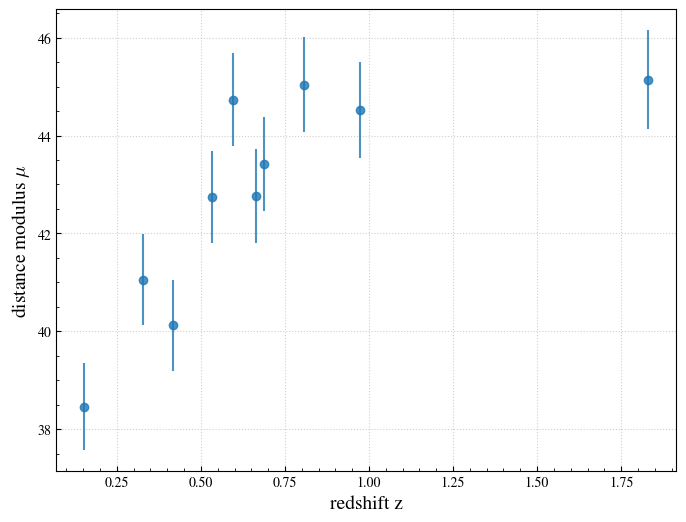

In [34]:
z_sample, mu_sample, dmu_sample  = astroML.datasets.generate_mu_z(10)#, random_state=0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(z_sample, mu_sample, yerr=dmu_sample, fmt='o', alpha=0.8)
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance modulus $\mu$', fontsize=14)
plt.grid()
plt.show()

In linear regression, we want to find the **weights** (intercept $\theta_0$ and slope $\theta_1$) that minimize the sum of squared residuals. The mathematical solution for this is:



Ordinary Mean Saquere

Ordinary Least Squares (OLS) Regression
OLS encuentra la linea que corresponda al mejor fit que minimiza la suma cuadrada de los residuales (error entre valores predecidos y los reales).

PASO A PASO:

1.- Obtenemos el sample, lo creamos o encontramos.

2.- Dividimos en dos dataset la muestra, sea para entrenar y luego testear.

3 .- Ajustamos (Fit) el modelo para luego hacer predicciones.

4.- Calculamos el MSE y evaluamos nuestro modelo.

OLS MSE: 0.6536995137170021


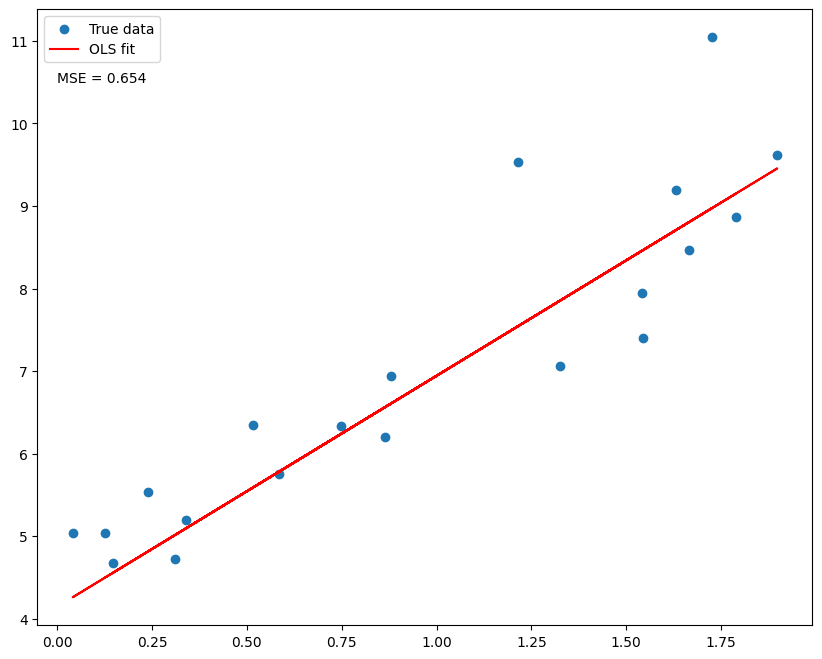

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generamos data sintética
np.random.seed(42)   # semilla para garantizar reproducibilidad
X = 2 * np.random.rand(100, 1)
m, n = 3, 4
y = n + m * X + np.random.randn(100, 1)  # Relación lineal con ruido

# Train-test split ( 80 entrenar, 20 para testear )
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit OLS Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("OLS MSE:", mse)

# Plot resultados
fig = plt.figure(figsize=(10,8))
plt.scatter(X_test, y_test, label="True data")
plt.plot(X_test, y_pred, color="red", label="OLS fit")
plt.text(0, 10.5, f'MSE = {np.round(mse, 3)}')
plt.legend()
plt.show()

Preguntas para ustedes,

¿Qué pasa si usamos todo el set de datos para entrenar y nada para testear?

¿Por qué OLS tiene problemas con datos complejos?

Regularización: Ridge y Lasso
OLS como habiamos conversado puede hacer overfitting cuando hay mucho ruido, ¿qué hacemos en ese caso?

Aqui entra la regularizacion, que busca bajar la varianza de los datos a costa de aumentar el bias.

Tenemos al menos dos opciones, las regresiones de Ridge y Lasso, estos agregan una penalizacion a los datos, para evitar el overfitting.

¿Cómo se diferencian?

Ridge Regression: Penaliza grandes coeficientes pero mantiene todas las caracteristicas de la muestra.

Lasso Regression: Deja unos coeficientes en 0 para asi favorecer el modelo.

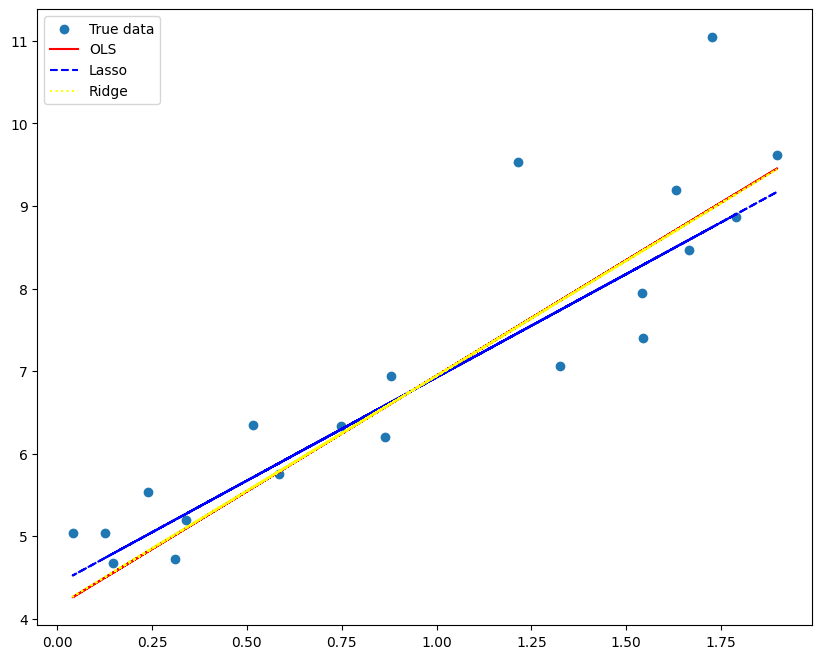

In [6]:
from sklearn.linear_model import Ridge, Lasso

# Fit Lasso and Ridge
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=0.1)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Predecimos
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

# Comparamos modelos
fig = plt.figure(figsize=(10,8))
plt.scatter(X_test, y_test, label="True data")
plt.plot(X_test, y_pred, color="red", label="OLS")
plt.plot(X_test, y_pred_lasso, color="blue", linestyle="dashed", label="Lasso")
plt.plot(X_test, y_pred_ridge, color="yellow", linestyle="dotted", label="Ridge")
plt.legend()
plt.show()

¿Cuándo deberíamos usar Lasso en lugar de Ridge?

Lasso es útil cuando esperamos que solo unas pocas características sean realmente importantes, ya que puede eliminar algunas estableciendo sus coeficientes en cero (soluciones dispersas).

Ridge es mejor cuando todas las características son relevantes, pero necesitamos reducir su impacto para evitar el sobreajuste (overfitting).

Ejemplo en Astronomía: Si tenemos un conjunto de datos de espectros de galaxias con muchas longitudes de onda, Lasso puede seleccionar las bandas más importantes. Ridge, en cambio, asegurará que todas las bandas contribuyan, pero con menor influencia.

Manejo de outliers: Regresión de Huber
Si tenemos outliers, OLS no hace el fit correctamente, pues los errores son muy grandes.

Así, la regresión de Huber combina OLS con una perdida absoluta, de esta forma puede manejar los outlier y ser más robusta.

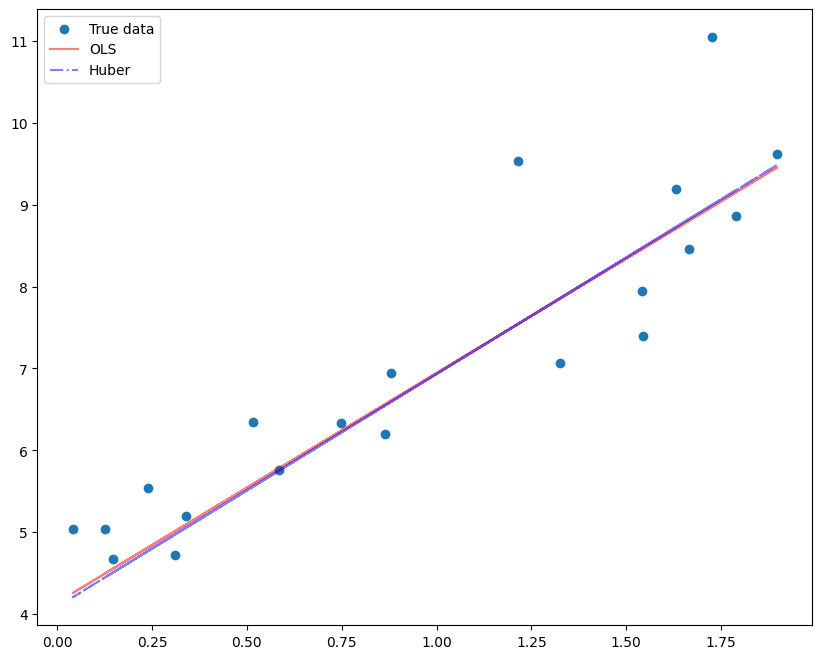

In [7]:
from sklearn.linear_model import HuberRegressor

# Agregamos outliers a la muestra
y_outliers = y.copy()
y_outliers[95:] += 10  # Agregamos errores grandes

# Fit Huber Regression
huber = HuberRegressor()
huber.fit(X_train, y_train.ravel())

# Predecimos
y_pred_huber = huber.predict(X_test)

# Comparamos modelos
fig = plt.figure(figsize=(10,8))
plt.scatter(X_test, y_test, label="True data")
plt.plot(X_test, y_pred, color="red", label="OLS", alpha=0.5)
plt.plot(X_test, y_pred_huber, color="blue", linestyle="dashdot",
         label="Huber",alpha=0.5)
plt.legend()
plt.show()

¿Cómo elegir entre OLS, Ridge, Lasso y Huber para datos astronómicos reales?

OLS: Bueno para conjuntos de datos simples y limpios, sin mucho ruido o valores atípicos.

Ridge: Útil cuando tenemos muchas características correlacionadas (por ejemplo, múltiples colores de galaxias).

Lasso: Ideal cuando queremos una selección automática de características (por ejemplo, identificar las líneas espectrales más relevantes).

Huber: Perfecto para datos con errores de medición o valores extremos (por ejemplo, estrellas variables).